# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# Simulating data

## Single df

### Creating

In [2]:
gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,
    

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    understimated_treatment_spillover_distance=300,
    overestimated_treatment_spillover_distance=500,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [3]:
gdf_output.columns.tolist()

['unit_id',
 'geometry',
 'x',
 'y',
 'T',
 'propensity',
 'T_tot',
 'T_tot_cat',
 'T_tot_cat_underestim',
 'T_tot_cat_overerestim',
 'ODR_1',
 'ODR_2',
 'ODR_3',
 'ODR_4',
 'ODR_5',
 'C1',
 'C2',
 'C3',
 'Cs',
 'tau',
 'tau_base',
 'spill',
 'distance_to_treatment',
 'decay',
 'Y',
 'Y_ns']

In [4]:
gdf_output[gdf_output['ODR_4']!=0][['unit_id','geometry', 'T_tot','T_tot_cat','T_tot_cat_underestim','T_tot_cat_overerestim', 'ODR_4']]

,unit_id,geometry,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,ODR_4
127,1127,POINT (600 700),1,treated_outer_ring4,control,treated_outer_ring4,1
128,1128,POINT (600 800),1,treated_outer_ring4,control,treated_outer_ring4,1
129,1129,POINT (600 900),1,treated_outer_ring4,control,treated_outer_ring4,1
130,1130,POINT (600 1000),1,treated_outer_ring4,control,treated_outer_ring4,1
131,1131,POINT (600 1100),1,treated_outer_ring4,control,treated_outer_ring4,1
132,1132,POINT (600 1200),1,treated_outer_ring4,control,treated_outer_ring4,1
133,1133,POINT (600 1300),1,treated_outer_ring4,control,treated_outer_ring4,1
145,1145,POINT (700 500),1,treated_outer_ring4,control,treated_outer_ring4,1
146,1146,POINT (700 600),1,treated_outer_ring4,control,treated_outer_ring4,1
154,1154,POINT (700 1400),1,treated_outer_ring4,control,treated_outer_ring4,1


In [5]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [6]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7441954388900344)

In [7]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5)

In [8]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,...,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y,Y_ns
207,1207,POINT (1000 700),1000,700,1,1.740855,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.243807,1.344463,0.652254,1.945121,1.945121,1.0,0.0,1.0,3.624659,3.408642
208,1208,POINT (1000 800),1000,800,1,0.932812,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.115865,0.123021,0.159922,1.683358,1.683358,1.0,0.0,1.0,2.073246,1.715839
209,1209,POINT (1000 900),1000,900,1,1.117712,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.183316,0.262733,0.868023,1.374603,1.374603,1.0,0.0,1.0,2.405956,2.063763
210,1210,POINT (1000 1000),1000,1000,1,-0.889052,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.180952,1.035598,-1.971555,1.594901,1.594901,1.0,0.0,1.0,0.981587,0.724878
211,1211,POINT (1000 1100),1000,1100,1,1.300728,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.371316,1.481621,-0.229653,1.666563,1.666563,1.0,0.0,1.0,2.728651,2.537534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,-0.328642,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-0.516081,-1.617301,1.095236,1.397004,1.397004,1.0,0.0,1.0,1.690212,1.507647
490,1490,POINT (2400 1000),2400,1000,1,-0.479833,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.272555,1.107807,-0.024889,1.315889,1.315889,1.0,0.0,1.0,0.894700,0.718322
491,1491,POINT (2400 1100),2400,1100,1,-1.935641,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.350171,-1.485618,1.292632,0.860993,0.860993,1.0,0.0,1.0,-0.039098,-0.342663
492,1492,POINT (2400 1200),2400,1200,1,-0.839411,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,1.687556,-1.077081,-1.858523,1.979412,1.979412,1.0,0.0,1.0,1.402042,1.402042


In [9]:
gdf_output.isna().any().any()

np.False_

In [10]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.2442', 'p-value simulated: 0.0010']

#### Visual checks

In [11]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

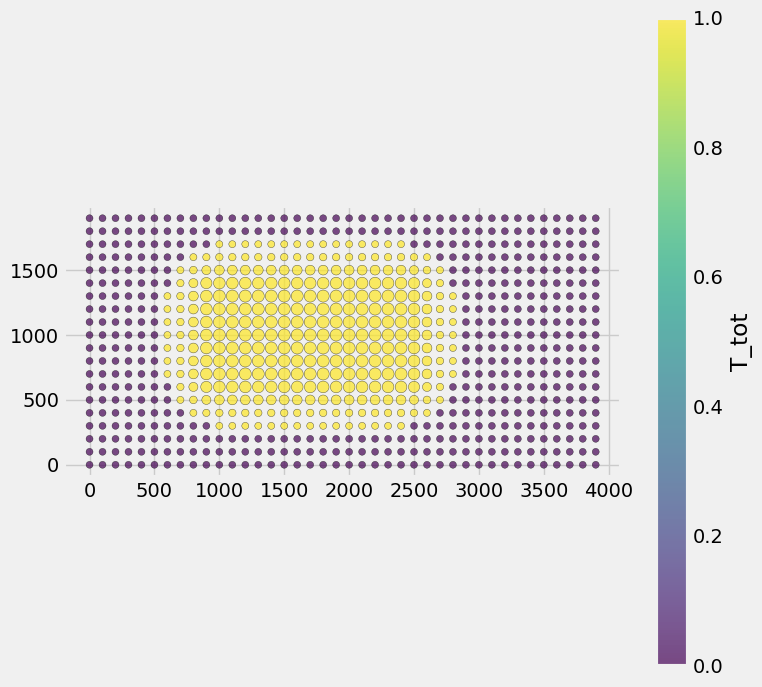

In [12]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

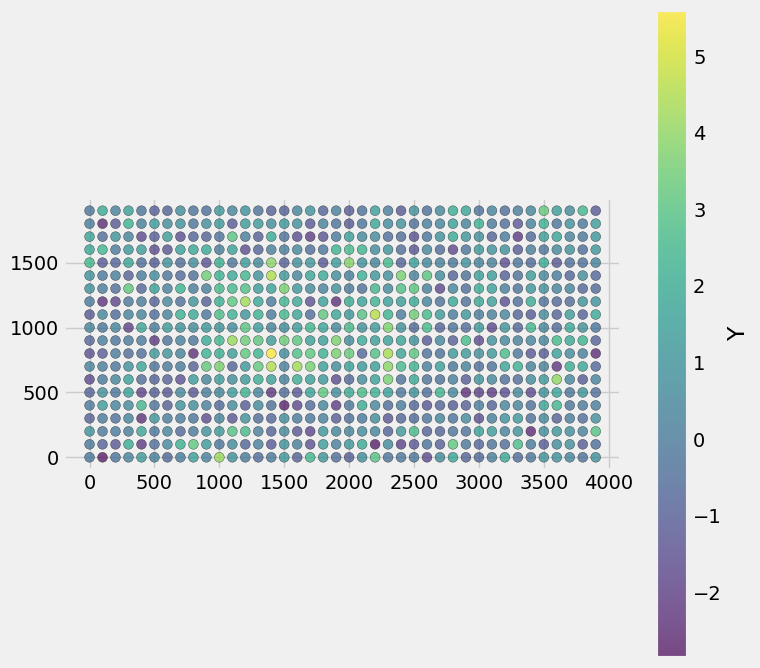

In [13]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

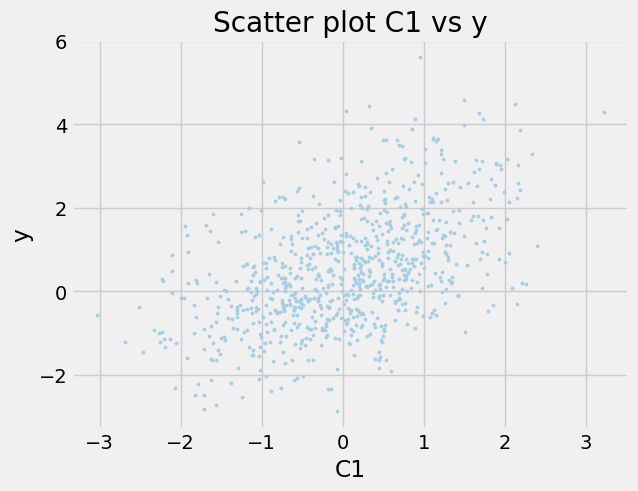

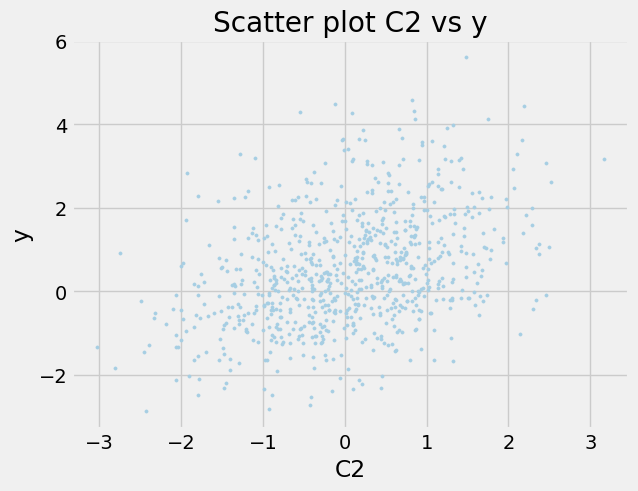

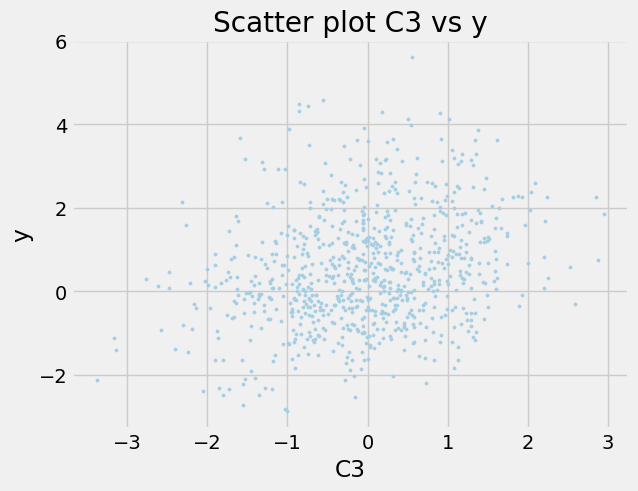

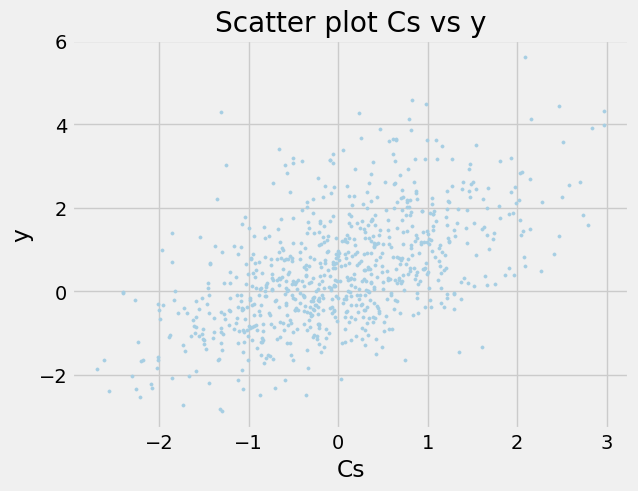

In [14]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [15]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

In [16]:
gdf_output4 = gdf_output.copy()
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'
df_encoded = pd.get_dummies(gdf_output4, columns=['treated'], dtype=int)
T_mult = df_encoded[['treated_inner_ring',
    'treated_outer_ring1',
    'treated_outer_ring2',
    'treated_outer_ring3',
    'treated_outer_ring4']].to_numpy()
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

##### Logit for T

In [17]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.387797
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Tue, 12 May 2026   Pseudo R-squ.:                0.002467
Time:                        18:19:04   Log-Likelihood:                -310.24
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                    0.4643
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8891      0.105    -18.010      0.000      -2.095      -1.684
x1            -0.0585      0.

##### Cross sectional linear difference in differences 

In [18]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     321.5
Date:                Tue, 12 May 2026   Prob (F-statistic):          1.04e-136
Time:                        18:19:04   Log-Likelihood:                -1042.6
No. Observations:                 800   AIC:                             2093.
Df Residuals:                     796   BIC:                             2112.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2399      0.034      7.067      0.0

In [19]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     254.5
Date:                Tue, 12 May 2026   Prob (F-statistic):          9.10e-116
Time:                        18:19:04   Log-Likelihood:                -1091.2
No. Observations:                 800   AIC:                             2190.
Df Residuals:                     796   BIC:                             2209.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1241      0.043      2.881      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [20]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:         800
Mean dependent var  :      0.5175                Number of Variables   :           8
S.D. dependent var  :      1.3610                Degrees of Freedom    :         792
Pseudo R-squared    :      0.5913
Spatial Pseudo R-squared:  0.5804
Log likelihood      :  -1026.8176
Sigma-square ML     :      0.7562                Akaike info criterion :    2069.635
S.E of regression   :      0.8696                Schwarz criterion     :    2107.112

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [21]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,1.945121,2.114427
208,1208,POINT (1000 800),1,1.683358,1.865448
209,1209,POINT (1000 900),1,1.374603,1.994954
210,1210,POINT (1000 1000),1,1.594901,1.671223
211,1211,POINT (1000 1100),1,1.666563,1.813912
...,...,...,...,...,...
489,1489,POINT (2400 900),1,1.397004,1.639251
490,1490,POINT (2400 1000),1,1.315889,1.086827
491,1491,POINT (2400 1100),1,0.860993,0.776328
492,1492,POINT (2400 1200),1,1.979412,1.080424


In [22]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.6312827433469796),
 np.float64(1.6607522397397694),
 np.float64(1.690221736132559))

In [23]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.6322562004671557)

###### For T tot

In [24]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.006956,1.039332,0.911893
128,1128,POINT (600 800),1,0.004900,0.732183,0.960624
129,1129,POINT (600 900),1,0.006968,1.041129,1.130130
130,1130,POINT (600 1000),1,0.006762,1.010298,0.313817
131,1131,POINT (600 1100),1,0.007360,1.099731,0.579885
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.007404,1.106285,0.536334
570,1570,POINT (2800 1000),1,0.011632,1.738025,0.933595
571,1571,POINT (2800 1100),1,0.007106,1.061722,0.649025
572,1572,POINT (2800 1200),1,0.006960,1.039963,0.563700


#### Multiple T DML

In [25]:
est = LinearDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)


In [26]:
est.fit(Y, T_mult, X=X, 
        #W=W
        )

In [27]:
te_pred = est.const_marginal_effect(X)
te_pred

array([[ 2.17364769,  1.49822919,  0.64767526, -0.15513473, -0.289283  ],
       [ 1.87126083,  1.25234666,  0.57016054, -0.29580715, -0.20301818],
       [ 2.37697425,  1.6712733 ,  0.76556246,  0.07894696, -0.32565515],
       ...,
       [ 2.65314532,  0.87045706,  0.85476163,  1.14587149, -0.44501342],
       [ 2.19111263,  1.55145604,  0.49083031, -0.18643619, -0.21337035],
       [ 1.08980312,  0.58277309, -0.18808863,  0.07830033,  0.34924976]],
      shape=(800, 5))

In [28]:
est2 = CausalForestDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

In [29]:
te_pred2 = est2.const_marginal_effect(X)
te_pred2

array([[ 1.90797863,  1.35985596,  0.71253925, -0.02845213, -0.21052703],
       [ 1.86387665,  1.17588085,  0.5507496 , -0.06665093, -0.15764616],
       [ 1.94822784,  1.45850995,  0.61622399,  0.06557555, -0.19327121],
       ...,
       [ 2.03410713,  1.30123255,  0.75805192, -0.0834257 , -0.40257411],
       [ 1.90153845,  1.42094338,  0.53661966,  0.01878393, -0.16074348],
       [ 1.40755518,  0.84068266,  0.1726404 ,  0.05325157,  0.20366652]],
      shape=(800, 5))

#### S learner with multiple treatments

In [30]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [31]:
ate, lb, ub

(array([ 1.84010306,  0.90498937,  0.27823939,  0.01505912, -0.01293578]),
 array([ 1.73794999,  0.78723379,  0.15308585, -0.11106022, -0.12309648]),
 array([1.94225613, 1.02274494, 0.40339293, 0.14117846, 0.09722492]))

In [32]:
ITE_df['treated'].unique()

array(['control', 'outer_ring4', 'outer_ring3', 'outer_ring2',
       'outer_ring1', 'inner_ring'], dtype=object)

In [33]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

outer_ring4 [np.float64(-0.07027451317435099), np.float64(-0.02344217484500731), np.float64(0.023390163484336375)] 0.0077861729788797586
outer_ring3 [np.float64(-0.042224580782521136), np.float64(0.03185843031358191), np.float64(0.10594144140968495)] 0.07685194967030924
outer_ring2 [np.float64(0.20004842587394436), np.float64(0.3193669532146487), np.float64(0.43868548055535306)] 0.5065231203790471
outer_ring1 [np.float64(0.8433544450173879), np.float64(0.9883955834775285), np.float64(1.133436721937669)] 0.9306631548050711
inner_ring [np.float64(1.6509645075792696), np.float64(1.7820461171869513), np.float64(1.913127726794633)] 1.5


In [34]:
ITE_df

,inner_ring,outer_ring1,outer_ring2,outer_ring3,outer_ring4,treated,ITE_real,Y
0,2.815451,1.699057,1.278421,0.077974,0.039154,control,0.0,-0.096707
1,1.996027,0.801481,0.335211,0.079469,0.004153,control,0.0,-0.111229
2,2.589043,1.731770,0.676906,0.255877,-0.075879,control,0.0,0.980694
3,0.375647,0.932692,0.048888,0.103726,0.053780,control,0.0,-0.909714
4,1.428855,0.969154,0.202788,0.193599,0.026119,control,0.0,-0.047118
...,...,...,...,...,...,...,...,...
795,2.704815,0.962160,0.691654,0.077875,-0.004712,control,0.0,0.284406
796,2.384455,0.807513,0.473601,-0.074823,-0.285393,control,0.0,1.138843
797,2.558197,0.496520,1.142668,-0.015313,-0.381418,control,0.0,1.096966
798,1.508104,0.961155,0.377247,0.009704,-0.060034,control,0.0,1.336582


In [35]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

np.float64(1.5)

## Generating multiple df for simulations

### Data generation

In [ ]:
list_of_rhos = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
dict_of_output_gdf = {}
for i in list_of_rhos:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 24,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = i,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,
    

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    understimated_treatment_spillover_distance=300,
    overestimated_treatment_spillover_distance=500,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:]}'] = single_gdf_output2

In [ ]:
dict_of_output_gdf.keys()

In [ ]:
moran_I_y= Moran(dict_of_output_gdf['gdf_rho_0_55']['Y'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

### Data saving

In [ ]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [ ]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite')
cursor = conn.cursor()

In [ ]:
repo_path_r_string

In [ ]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_file(
        repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite',
        layer=k,
        driver="SQLite",
        #spatialite=True,
        #if_exists="replace"
    )